<a href="https://colab.research.google.com/github/sayandeepmaity/luminator/blob/main/tdoa_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
from itertools import combinations

# Paths for the files
train_path = '/content/drive/My Drive/gunshotdata/dmodel1/train_data.csv'
test_path  = '/content/drive/My Drive/gunshotdata/dmodel1/test_data.csv'

# Load both train and test data
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# Define a 6-sensor array and all 15 pairs
sensors = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 1.0]
])
pairs = list(combinations(range(len(sensors)), 2))  # 15 (i,j) pairs

# Function to generate Model 2 features
def generate_model2_features(df):
    rows = []
    for _, row in df.iterrows():
        # keep all existing features
        base_feats = row.values.tolist()

        # random source position in a 2×2×2 m cube
        src = np.random.uniform(0, 2, size=3)
        dists = np.linalg.norm(sensors - src, axis=1)

        tdoa_feats, corr_vals = [], []
        for (i, j) in pairs:
            # true TDOA (sec) + small noise
            tau_true = (dists[i] - dists[j]) / 343.0
            noise    = np.random.normal(0, 1e-4)
            tau       = tau_true + noise

            # simulated quality metrics
            corr = np.clip(np.exp(-abs(noise)/1e-4) * np.random.uniform(0.8, 1.0), 0, 1)
            snr  = np.random.uniform(10, 30) - abs(noise)*1e5

            tdoa_feats += [tau, corr, snr]
            corr_vals.append(corr)

        # label = index of the pair with highest correlation
        best_pair = int(np.argmax(corr_vals))

        rows.append(base_feats + tdoa_feats + [best_pair])

    return pd.DataFrame(rows, columns=df.columns.tolist() +
                        [f"tau_{i}{j}" for (i, j) in pairs] +
                        [f"corr_{i}{j}" for (i, j) in pairs] +
                        [f"snr_{i}{j}" for (i, j) in pairs] + ['best_pair'])

# Apply the function to both train and test datasets
train_model2_df = generate_model2_features(train_df)
test_model2_df = generate_model2_features(test_df)

# Save the modified datasets for Model 2
train_model2_df.to_csv('/content/drive/My Drive/gunshotdata/dmodel2/train_data_model2.csv', index=False)
test_model2_df.to_csv('/content/drive/My Drive/gunshotdata/dmodel2/test_data_model2.csv', index=False)

print("Model 2 features added and saved as new files.")


Model 2 features added and saved as new files.


In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1. Paths to your Model-2 data
train_path = '/content/drive/My Drive/gunshotdata/dmodel2/train_data_model2.csv'
test_path  = '/content/drive/My Drive/gunshotdata/dmodel2/test_data_model2.csv'

# 2. Load the datasets
df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

# 3. Separate features and target
#    - 'best_pair' is our new label for Model-2
#    - drop any original columns you don’t want as features (e.g. 'label' from Model-1)
X_train = df_train.drop(['best_pair', 'label'], axis=1)
y_train = df_train['best_pair']

X_test  = df_test.drop(['best_pair', 'label'], axis=1)
y_test  = df_test['best_pair']

# 4. Initialize & train the classifier
clf2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
clf2.fit(X_train, y_train)

# 7. Save the trained Model-2
model2_path = '/content/drive/My Drive/gunshotdata/dmodel2/model2_tdoaselector.pkl'
joblib.dump(clf2, model2_path)
print(f"Model 2 saved to: {model2_path}")


Model 2 saved to: /content/drive/My Drive/gunshotdata/dmodel2/model2_tdoaselector.pkl


In [10]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load test set and trained model
df_test   = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel2/test_data_model2.csv')
clf2      = joblib.load('/content/drive/My Drive/gunshotdata/dmodel2/model2_tdoaselector.pkl')

# 2. Prepare X and y
X_test = df_test.drop(['best_pair','label'], axis=1)
y_test = df_test['best_pair']

# 3. Predict
y_pred = clf2.predict(X_test)

# 4. Basic metrics
miscls = (y_pred != y_test).sum()
acc    = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)
cm     = confusion_matrix(y_test, y_pred)

print(f"Misclassifications: {miscls} / {len(y_test)}")
print(f"Accuracy:          {acc:.4f}\n")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)


Misclassifications: 794 / 20000
Accuracy:          0.9603

Classification Report:
              precision    recall  f1-score   support

           0     0.9694    0.9629    0.9662      1349
           1     0.9591    0.9528    0.9559      1355
           2     0.9584    0.9681    0.9632      1380
           3     0.9552    0.9699    0.9625      1363
           4     0.9613    0.9657    0.9635      1311
           5     0.9549    0.9625    0.9587      1387
           6     0.9674    0.9578    0.9626      1302
           7     0.9599    0.9541    0.9570      1330
           8     0.9685    0.9584    0.9634      1250
           9     0.9580    0.9557    0.9569      1288
          10     0.9599    0.9570    0.9585      1350
          11     0.9594    0.9544    0.9569      1338
          12     0.9521    0.9633    0.9577      1362
          13     0.9709    0.9635    0.9672      1314
          14     0.9518    0.9576    0.9547      1321

    accuracy                         0.9603     2000

Misclassifications: 794 / 20000
Accuracy:          0.9603

Classification Report:
              precision    recall  f1-score   support

           0     0.9694    0.9629    0.9662      1349
           1     0.9591    0.9528    0.9559      1355
           2     0.9584    0.9681    0.9632      1380
           3     0.9552    0.9699    0.9625      1363
           4     0.9613    0.9657    0.9635      1311
           5     0.9549    0.9625    0.9587      1387
           6     0.9674    0.9578    0.9626      1302
           7     0.9599    0.9541    0.9570      1330
           8     0.9685    0.9584    0.9634      1250
           9     0.9580    0.9557    0.9569      1288
          10     0.9599    0.9570    0.9585      1350
          11     0.9594    0.9544    0.9569      1338
          12     0.9521    0.9633    0.9577      1362
          13     0.9709    0.9635    0.9672      1314
          14     0.9518    0.9576    0.9547      1321

    accuracy                         0.9603     2000

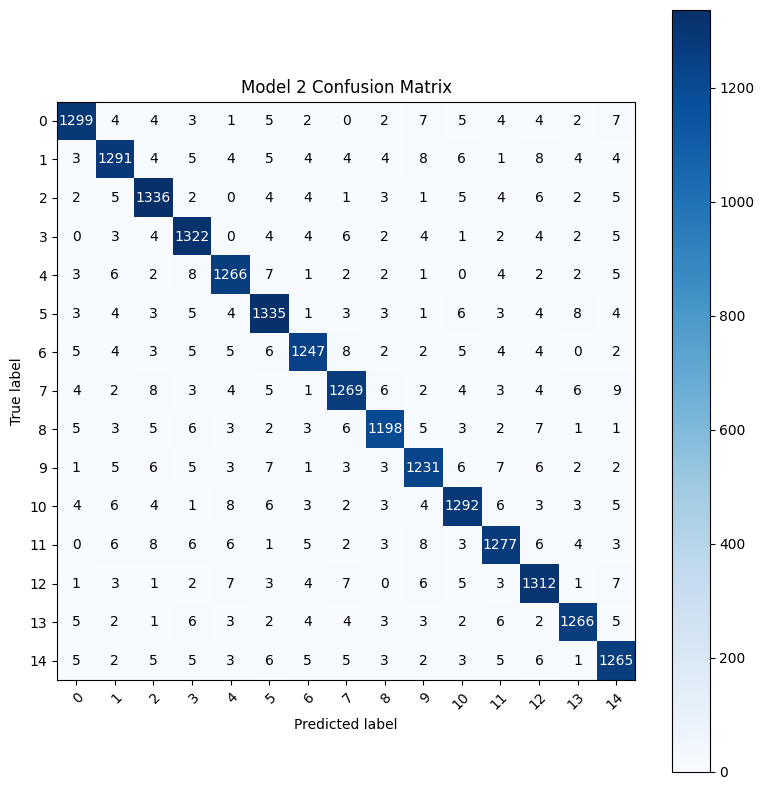

In [11]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Load test set and trained model
df_test = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel2/test_data_model2.csv')
clf2    = joblib.load('/content/drive/My Drive/gunshotdata/dmodel2/model2_tdoaselector.pkl')

# 2. Prepare X and y
X_test = df_test.drop(['best_pair','label'], axis=1)
y_test = df_test['best_pair']

# 3. Predict
y_pred = clf2.predict(X_test)

# 4. Basic metrics
miscls = (y_pred != y_test).sum()
acc    = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)
cm     = confusion_matrix(y_test, y_pred)

print(f"Misclassifications: {miscls} / {len(y_test)}")
print(f"Accuracy:          {acc:.4f}\n")
print("Classification Report:")
print(report)

# 5. Plot confusion matrix with matplotlib
labels = [str(i) for i in range(cm.shape[0])]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Set tick labels
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    xlabel='Predicted label',
    ylabel='True label',
    title='Model 2 Confusion Matrix'
)

# Rotate the tick labels and set alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell with its count
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()


In [14]:
import numpy as np
import pandas as pd

# Read dataset
train_data = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel2/train_data_model2.csv')
test_data  = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel2/test_data_model2.csv')

# Print column names of both datasets
print("Column names in training data:")
print(train_data.columns)

print("\nColumn names in testing data:")
print(test_data.columns)


Column names in training data:
Index(['correlation', 'phase', 'amplitude', 'energy', 'spectral_centroid',
       'snr', 'label', 'tau_01', 'tau_02', 'tau_03', 'tau_04', 'tau_05',
       'tau_12', 'tau_13', 'tau_14', 'tau_15', 'tau_23', 'tau_24', 'tau_25',
       'tau_34', 'tau_35', 'tau_45', 'corr_01', 'corr_02', 'corr_03',
       'corr_04', 'corr_05', 'corr_12', 'corr_13', 'corr_14', 'corr_15',
       'corr_23', 'corr_24', 'corr_25', 'corr_34', 'corr_35', 'corr_45',
       'snr_01', 'snr_02', 'snr_03', 'snr_04', 'snr_05', 'snr_12', 'snr_13',
       'snr_14', 'snr_15', 'snr_23', 'snr_24', 'snr_25', 'snr_34', 'snr_35',
       'snr_45', 'best_pair'],
      dtype='object')

Column names in testing data:
Index(['correlation', 'phase', 'amplitude', 'energy', 'spectral_centroid',
       'snr', 'label', 'tau_01', 'tau_02', 'tau_03', 'tau_04', 'tau_05',
       'tau_12', 'tau_13', 'tau_14', 'tau_15', 'tau_23', 'tau_24', 'tau_25',
       'tau_34', 'tau_35', 'tau_45', 'corr_01', 'corr_02', 'corr_